# Sistema de Recuperação da Informação para Identificação de Perfis de Crédito Semelhantes

## 1. Introdução e Objetivo

Este projeto apresenta o desenvolvimento de um Sistema de Recuperação da Informação (SRI) aplicado à identificação de perfis semelhantes de clientes em bases de crédito. A proposta consiste em transformar registros tabulares em documentos textuais, permitindo a aplicação de técnicas clássicas de Recuperação da Informação para localizar clientes com características próximas às de uma consulta fornecida.

O trabalho foi desenvolvido como atividade prática da disciplina de Recuperação da Informação e contempla a implementação de métodos de indexação, ranqueamento e avaliação amplamente utilizados na literatura da área.

Foram avaliados dois modelos de recuperação:

* **TF-IDF (Term Frequency – Inverse Document Frequency)**, implementado manualmente;
* **BM25 (Best Matching 25)**, utilizado como modelo probabilístico de comparação.

Os experimentos foram realizados utilizando o conjunto de dados **German Credit Data**, composto por informações socioeconômicas e financeiras de tomadores de crédito. Cada registro foi convertido para uma representação textual baseada em pares atributo-valor, permitindo que os algoritmos de recuperação operassem sobre um corpus documental.

O desempenho dos modelos foi avaliado por meio das métricas clássicas de Recuperação da Informação:

* **Precision@10 (P@10)**
* **Precision@20 (P@20)**
* **Precision@50 (P@50)**
* **Precision@100 (P@100)**
* **Mean Average Precision (MAP)**

Além da comparação entre TF-IDF e BM25, o trabalho também investiga o impacto da representação dos atributos na qualidade da recuperação, analisando o efeito da discretização da variável idade sobre o tamanho do vocabulário e o desempenho dos modelos.

---

## 2. Configuração do Ambiente e Importações

Nesta etapa são importadas as bibliotecas responsáveis pelo processamento dos dados, manipulação de estruturas matriciais, cálculo das métricas de recuperação, visualização dos resultados e processamento textual.

As principais bibliotecas utilizadas foram:

* **NumPy** (`numpy`) para operações numéricas e manipulação de matrizes;
* **Pandas** (`pandas`) para carregamento e tratamento dos dados;
* **Matplotlib** (`matplotlib`) para geração de gráficos;
* **NLTK** (`nltk`) para tokenização e pré-processamento textual;
* **Rank-BM25** (`rank_bm25`) para implementação do modelo probabilístico BM25.

Também são carregados os recursos necessários do NLTK, incluindo os mecanismos de tokenização e listas de palavras irrelevantes (*stopwords*), utilizados durante a etapa de pré-processamento dos documentos.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rank_bm25


### Carregando bibliotecas

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from rank_bm25 import BM25Okapi
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import re
import math
import numpy as np
from collections import Counter

# Importação do Dataset de Referência via scikit-learn
from sklearn.datasets import fetch_20newsgroups

# Download dos recursos essenciais do NLTK (Incluindo a correção para as novas versões)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Definição do conjunto de Stop Words em inglês
STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3. Arquitetura do Motor de RI (RIEngine)
Abaixo está definida a classe principal `RIEngine`. Ela encapsula todo o pipeline matemático e computacional do TF-IDF (sem auxílio de bibliotecas como o scikit-learn):

* **Pré-processamento:** Conversão para minúsculas, remoção de pontuações/caracteres não-alfabéticos e eliminação de *stop words*.
* **Indexação:** Construção do vocabulário único e mapeamento de termos para índices.
* **Cálculo do IDF Suavizado:** $IDF(t) = \log\left(\frac{N}{1 + DF(t)}\right)$
* **Cálculo do TF-IDF:** Multiplicação da frequência termo-documento normalizada pelo seu respectivo IDF.
* **Similaridade do Cosseno:** Medição do ângulo vetorial entre a Query e os Documentos.
* **Avaliação:** Computação manual de métricas de relevância: **Precision@K (P@10, P@20, P@50, P@100)** e o **MAP (Mean Average Precision)** através do Average Precision (AP).

#### RIEngine para o German Credit Risk

In [ ]:
class RIEngineCredit:

    def __init__(self):
        self.corpus_docs = []
        self.corpus_labels = []
        self.query_docs = []
        self.query_labels = []
        self.categories = []

    # ======================================================
    # PRÉ-PROCESSAMENTO
    # ======================================================
    # ======================================================
    # PRÉ-PROCESSAMENTO
    # ======================================================
    def preprocess(self, text):
        """
        Preserva atributos compostos como:
        age_67
        sex_male
        job_2
        housing_own
        purpose_radio/tv
        """

        text = text.lower()

        # Mantém letras, números, underscore e /
        tokens = re.findall(r'[a-z0-9_/]+', text)

        tokens = [
            token
            for token in tokens
            if token not in STOP_WORDS
        ]

        return tokens

    # ======================================================
    # INDEXAÇÃO
    # ======================================================
    def build_index(self):
        print("\n[1] Pré-processando documentos...")
        self.tokenized_corpus = [
            self.preprocess(doc)
            for doc in self.corpus_docs
        ]

        # Construção do Vocabulário Único
        self.vocabulary = sorted(set(
            token
            for doc in self.tokenized_corpus
            for token in doc
        ))
        print(f"Tamanho do vocabulário: {len(self.vocabulary)}")

        # Mapa Termo -> Índice
        self.term_to_index = {
            term: idx
            for idx, term in enumerate(self.vocabulary)
        }

    # ======================================================
    # IDF MANUAL
    # ======================================================
    def compute_idf(self):
        print("\n[2] Calculando IDF de forma otimizada...")

        N = len(self.tokenized_corpus)

        df_counts = Counter()

        for doc in self.tokenized_corpus:
            df_counts.update(set(doc))

        self.idf = {}

        for term in self.vocabulary:
            df = df_counts[term]

            # IDF suavizado
            self.idf[term] = math.log((N + 1) / (df + 1)) + 1

        print("Cálculo do IDF concluído com sucesso!")


    # ======================================================
    # TF-IDF MANUAL
    # ======================================================
    def compute_tfidf(self):
        print("\n[3] Calculando TF-IDF com otimização de memória...")

        num_docs = len(self.tokenized_corpus)
        num_words = len(self.vocabulary)

        # OTIMIZAÇÃO: Criamos a matriz final diretamente na memória.
        # O dtype=np.float32 corta o uso de memória RAM pela metade, evitando o crash do Colab.
        self.document_vectors = np.zeros((num_docs, num_words), dtype=np.float32)

        for doc_idx, doc in enumerate(self.tokenized_corpus):
            counter = Counter(doc)
            total_terms = len(doc)

            if total_terms == 0:
                continue

            # O loop roda apenas para as palavras ÚNICAS do documento atual (muito rápido)
            for term, freq in counter.items():
                if term in self.term_to_index:
                    # TF Linearizado
                    tf = freq / total_terms

                    # TF-IDF
                    tfidf = tf * self.idf[term]

                    word_idx = self.term_to_index[term]

                    # Atribuição direta na linha e coluna exatas
                    self.document_vectors[doc_idx, word_idx] = tfidf

        print(f"Matriz TF-IDF {self.document_vectors.shape} criada com sucesso e segura na RAM!")

    # ======================================================
    # QUERY -> VETOR
    # ======================================================
    def vectorize_query(self, query):
        tokens = self.preprocess(query)
        vector = np.zeros(len(self.vocabulary))
        counter = Counter(tokens)
        total_terms = len(tokens)

        for term, freq in counter.items():
            if term in self.term_to_index:
                tf = freq / total_terms
                tfidf = tf * self.idf[term]
                idx = self.term_to_index[term]
                vector[idx] = tfidf
        return vector

    # ======================================================
    # SIMILARIDADE COSSENO MANUAL
    # ======================================================
    def cosine_similarity_manual(self, a, b):

        norm_a = np.linalg.norm(a)
        norm_b = np.linalg.norm(b)

        if norm_a == 0 or norm_b == 0:
            return 0.0

        return np.dot(a, b) / (norm_a * norm_b)

    # ======================================================
    # RANQUEAMENTO
    # ======================================================
    def rank_documents(self, query_text):
        query_vector = self.vectorize_query(query_text)
        scores = []

        for idx, doc_vector in enumerate(self.document_vectors):
            similarity = self.cosine_similarity_manual(query_vector, doc_vector)
            scores.append((idx, similarity))

        # Ordenação decrescente pelo score de similaridade
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        return scores

    # ======================================================
    # AVALIAÇÃO EXPERIMENTAL
    # ======================================================
    def evaluate(self):
        print("\n[4] Executando avaliação experimental...")
        metrics = {
            'P@10': [], 'P@20': [], 'P@50': [], 'P@100': [], 'AP': []
        }

        for q_idx, query in enumerate(self.query_docs):
            query_label = self.query_labels[q_idx]
            ranking = self.rank_documents(query)
            ranked_indices = [r[0] for r in ranking]

            # Vetor binário de relevância (1 se for da mesma categoria, 0 caso contrário)
            relevance = [
                1 if self.corpus_labels[idx] == query_label else 0
                for idx in ranked_indices
            ]

            # Precision@K
            metrics['P@10'].append(np.mean(relevance[:10]))
            metrics['P@20'].append(np.mean(relevance[:20]))
            metrics['P@50'].append(np.mean(relevance[:50]))
            metrics['P@100'].append(np.mean(relevance[:100]))

            # Average Precision (AP) para cálculo do MAP
            precisions = []
            relevant_found = 0
            for i, rel in enumerate(relevance):
                if rel == 1:
                    relevant_found += 1
                    precisions.append(relevant_found / (i + 1))

            ap = np.mean(precisions) if precisions else 0
            metrics['AP'].append(ap)

        # Média de todas as consultas
        results = {metric: np.mean(values) for metric, values in metrics.items()}
        return results

    # ======================================================
    # EXEMPLO VISUAL DE RECUPERAÇÃO
    # ======================================================
    def show_example(self, query_id=0, top_k=5):
        print("\n" + "="*50)
        print("EXEMPLO DE RECUPERAÇÃO DE DOCUMENTOS")
        print("="*50)

        query = self.query_docs[query_id]
        ranking = self.rank_documents(query)

        print(f"\n📝 QUERY (ID: {query_id}):\n")
        print(query[:400] + "...")
        print("\n🏆 TOP DOCUMENTOS RETORNADOS:\n")

        for pos, (doc_idx, score) in enumerate(ranking[:top_k]):
            print("-" * 40)
            print(f"Rank: {pos+1} | Similaridade: {score:.4f}")
            if len(self.categories) > 0:
                print(f"Categoria Real: {self.categories[self.corpus_labels[doc_idx]]}")
            print(f"\nTrecho do documento:\n{self.corpus_docs[doc_idx][:250]}...")

    # ======================================================
    # PLOTAGEM DE GRÁFICOS
    # ======================================================
    def plot_results(self, results, title):
        metrics_plot = {
            'P@10': results['P@10'], 'P@20': results['P@20'],
            'P@50': results['P@50'], 'P@100': results['P@100']
        }
        plt.figure(figsize=(8, 5))
        plt.plot(list(metrics_plot.keys()), list(metrics_plot.values()), marker='o', color='b', linestyle='-')
        plt.title(title)
        plt.xlabel("Métricas de Corte (K)")
        plt.ylabel("Precisão Média")
        plt.grid(True, linestyle='--')
        plt.show()



    def build_bm25(self):

      print("\n[BM25] Construindo índice BM25...")

      self.bm25 = BM25Okapi(self.tokenized_corpus)

      print("Índice BM25 criado com sucesso!")


    # Rankeamento
    def rank_documents_bm25(self, query_text):

        query_tokens = self.preprocess(query_text)

        scores = self.bm25.get_scores(query_tokens)

        ranking = list(enumerate(scores))

        ranking.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return ranking
    # Avaliação BM25
    def evaluate_bm25(self):

        print("\n[BM25] Executando avaliação experimental...")

        metrics = {
            'P@10': [],
            'P@20': [],
            'P@50': [],
            'P@100': [],
            'AP': []
        }

        for q_idx, query in enumerate(self.query_docs):

            query_label = self.query_labels[q_idx]

            ranking = self.rank_documents_bm25(query)

            ranked_indices = [r[0] for r in ranking]

            relevance = [
                1 if self.corpus_labels[idx] == query_label else 0
                for idx in ranked_indices
            ]

            metrics['P@10'].append(np.mean(relevance[:10]))
            metrics['P@20'].append(np.mean(relevance[:20]))
            metrics['P@50'].append(np.mean(relevance[:50]))
            metrics['P@100'].append(np.mean(relevance[:100]))

            precisions = []

            relevant_found = 0

            for i, rel in enumerate(relevance):

                if rel == 1:

                    relevant_found += 1

                    precisions.append(
                        relevant_found / (i + 1)
                    )

            ap = np.mean(precisions) if precisions else 0

            metrics['AP'].append(ap)

        return {
            metric: np.mean(values)
            for metric, values in metrics.items()
        }

    def show_example_bm25(self, query_id=0, top_k=5):

        print("\n" + "="*50)
        print("EXEMPLO DE RECUPERAÇÃO BM25")
        print("="*50)

        query = self.query_docs[query_id]

        ranking = self.rank_documents_bm25(query)

        print(f"\n📝 QUERY (ID: {query_id}):\n")
        print(query)

        print("\n🏆 TOP DOCUMENTOS RETORNADOS:\n")

        for pos, (doc_idx, score) in enumerate(ranking[:top_k]):

            print("-" * 40)

            print(
                f"Rank: {pos+1} | Score BM25: {score:.4f}"
            )

            print(
                f"\nTrecho:\n{self.corpus_docs[doc_idx]}"
            )


## 4. Carregamento dos Datasets



### 4.2. Dataset  German Credit
Para enriquecer a análise do comportamento do algoritmo, adaptamos uma base de dados, que faz parte da proposta de nossa pesquisa na disciplina, puramente tabular através do processo de **Textualização**. Cada registro (linha) é transformado em uma string contínua contendo rótulos descritivos (*Ex: age_30 sex_male job_2...*).

In [ ]:
def load_german_credit(engine, csv_path):
    print("\n" + "="*50)
    print("CARREGANDO E TEXTUALIZANDO: GERMAN CREDIT")
    print("="*50)

    df = pd.read_csv(csv_path, index_col=0)

    def build_profile(row):

      age = row['Age']

      # Discretização da idade
      if age <= 25:
          age_group = "young"
      elif age <= 40:
          age_group = "adult"
      elif age <= 60:
          age_group = "middle"
      else:
          age_group = "senior"

      # Normalização das categorias
      sex = str(row['Sex']).replace(" ", "_")
      housing = str(row['Housing']).replace(" ", "_")
      saving = str(row['Saving accounts']).replace(" ", "_")
      checking = str(row['Checking account']).replace(" ", "_")

      profile = (
          f"age_{age_group} "
          f"sex_{sex} "
          f"job_{row['Job']} "
          f"housing_{housing} "
          f"saving_{saving} "
          f"checking_{checking}"
      )

      return profile.lower().replace('nan', 'unknown')

    df['text_profile'] = df.apply(build_profile, axis=1)
    labels = df['Purpose'].astype('category').cat.codes.values

    # Separação Query vs Corpus
    engine.query_docs = df['text_profile'].iloc[:100].tolist()
    engine.query_labels = labels[:100]

    engine.corpus_docs = df['text_profile'].iloc[100:].tolist()
    engine.corpus_labels = labels[100:]

    print(f"Sucesso! Perfis gerados no Corpus: {len(engine.corpus_docs)}")
    print(f"Sucesso! Perfis gerados para Queries: {len(engine.query_docs)}")

## 5. Pipeline de Execução e Resultados



### 5.2. Experimento : German Credit (TF-IDF Manual e BM25)
*Atenção: Garanta que o arquivo `german_credit_data.csv` esteja carregado na raiz do diretório de arquivos do seu Colab antes de rodar a célula abaixo.*

### Executando German Credit Risk

In [ ]:
engine_credit.build_bm25()

results_bm25 = engine_credit.evaluate_bm25()


CARREGANDO E TEXTUALIZANDO: GERMAN CREDIT
Sucesso! Perfis gerados no Corpus: 900
Sucesso! Perfis gerados para Queries: 100

[1] Pré-processando documentos...
Tamanho do vocabulário: 22

Exemplo de documento tokenizado:
['age_middle', 'sex_male', 'job_1', 'housing_rent', 'saving_moderate', 'checking_unknown']

Primeiros 30 termos do vocabulário:
['age_adult', 'age_middle', 'age_senior', 'age_young', 'checking_little', 'checking_moderate', 'checking_rich', 'checking_unknown', 'housing_free', 'housing_own', 'housing_rent', 'job_0', 'job_1', 'job_2', 'job_3', 'saving_little', 'saving_moderate', 'saving_quite_rich', 'saving_rich', 'saving_unknown', 'sex_female', 'sex_male']

Vocabulário final: 22 termos

EXECUTANDO TF-IDF

[2] Calculando IDF de forma otimizada...
Cálculo do IDF concluído com sucesso!

[3] Calculando TF-IDF com otimização de memória...
Matriz TF-IDF (900, 22) criada com sucesso e segura na RAM!

[4] Executando avaliação experimental...

MÉTRICAS FINAIS - TF-IDF
P@10: 0.2720

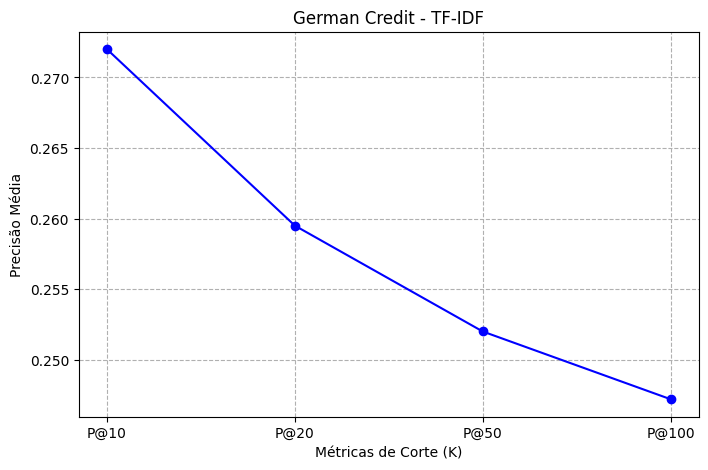


EXECUTANDO BM25

[BM25] Construindo índice BM25...
Índice BM25 criado com sucesso!

[BM25] Executando avaliação experimental...

MÉTRICAS FINAIS - BM25
P@10: 0.2450
P@20: 0.2515
P@50: 0.2486
P@100: 0.2523
MAP (Mean Average Precision): 0.2460



EXEMPLO DE RECUPERAÇÃO BM25

📝 QUERY (ID: 0):

age_senior sex_male job_2 housing_own saving_unknown checking_little

🏆 TOP DOCUMENTOS RETORNADOS:

----------------------------------------
Rank: 1 | Score BM25: 5.8876

Trecho:
age_senior sex_female job_3 housing_own saving_unknown checking_little
----------------------------------------
Rank: 2 | Score BM25: 5.5741

Trecho:
age_senior sex_male job_2 housing_own saving_unknown checking_unknown
----------------------------------------
Rank: 3 | Score BM25: 5.5741

Trecho:
age_senior sex_male job_2 housing_own saving_unknown checking_unknown
----------------------------------------
Rank: 4 | Score BM25: 5.5741

Trecho:
age_senior sex_male job_2 housing_own saving_unknown checking_unknown
----------

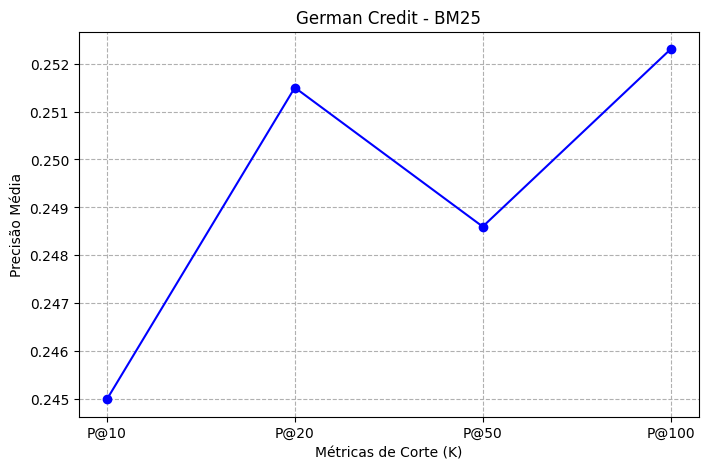


COMPARAÇÃO TF-IDF x BM25
Métrica        TF-IDF         BM25           
P@10           0.2720         0.2450         
P@20           0.2595         0.2515         
P@50           0.2520         0.2486         
P@100          0.2472         0.2523         
MAP            0.2473         0.2460         


In [ ]:
# =====================================================
# INICIALIZAÇÃO
# =====================================================

engine_credit = RIEngineCredit()

# =====================================================
# CARREGAMENTO DOS DADOS
# =====================================================

load_german_credit(
    engine_credit,
    "/content/drive/MyDrive/german_credit_data.csv"
)

# =====================================================
# CONSTRUÇÃO DO ÍNDICE
# =====================================================

engine_credit.build_index()

print("\nExemplo de documento tokenizado:")
print(engine_credit.tokenized_corpus[0])

print("\nPrimeiros 30 termos do vocabulário:")
print(engine_credit.vocabulary[:30])

print(f"\nVocabulário final: {len(engine_credit.vocabulary)} termos")

# =====================================================
# TF-IDF
# =====================================================

print("\n" + "="*50)
print("EXECUTANDO TF-IDF")
print("="*50)

engine_credit.compute_idf()
engine_credit.compute_tfidf()

results_tfidf = engine_credit.evaluate()

print("\n================================================")
print("MÉTRICAS FINAIS - TF-IDF")
print("================================================")

for metric, value in results_tfidf.items():

    if metric == 'AP':
        print(f"MAP (Mean Average Precision): {value:.4f}")
    else:
        print(f"{metric}: {value:.4f}")

print("\n")
engine_credit.show_example(query_id=0)

engine_credit.plot_results(
    results_tfidf,
    "German Credit - TF-IDF"
)

# =====================================================
# BM25
# =====================================================

print("\n" + "="*50)
print("EXECUTANDO BM25")
print("="*50)

engine_credit.build_bm25()

results_bm25 = engine_credit.evaluate_bm25()

print("\n================================================")
print("MÉTRICAS FINAIS - BM25")
print("================================================")

for metric, value in results_bm25.items():

    if metric == 'AP':
        print(f"MAP (Mean Average Precision): {value:.4f}")
    else:
        print(f"{metric}: {value:.4f}")

print("\n")
engine_credit.show_example_bm25(query_id=0)

engine_credit.plot_results(
    results_bm25,
    "German Credit - BM25"
)

# =====================================================
# COMPARAÇÃO FINAL
# =====================================================

print("\n" + "="*60)
print("COMPARAÇÃO TF-IDF x BM25")
print("="*60)

print(
    f"{'Métrica':<15}"
    f"{'TF-IDF':<15}"
    f"{'BM25':<15}"
)

for metric in ['P@10', 'P@20', 'P@50', 'P@100', 'AP']:

    nome = (
        'MAP'
        if metric == 'AP'
        else metric
    )

    print(
        f"{nome:<15}"
        f"{results_tfidf[metric]:<15.4f}"
        f"{results_bm25[metric]:<15.4f}"
    )